### Import necessary libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statistics
import pickle
from scipy import stats
from colorama import Fore
from sklearn.mixture import BayesianGaussianMixture
from scipy.stats import norm


# Read in data

### Decide if splitting sets or not

In [2]:
split = True # rest in between sets negates fatigue

if split:
    raw_df = pd.read_csv("/home/abbie/projects/TECH646-Haptic-Results/data/raw_data_split.csv")
    raw_df.set_index('subject_trial', inplace=True)
else:
    raw_df = pd.read_csv("/home/abbie/projects/TECH646-Haptic-Results/data/raw_data.csv")
    raw_df.set_index('subject', inplace=True)

### Decide for all or only small

In [3]:
small_only = True # switching up between big and small created inconsistency

if small_only:
    raw_df = raw_df.drop(raw_df.filter(like='big', axis=1), axis=1)

print(raw_df.shape[1])

15


### Plot all the raw data

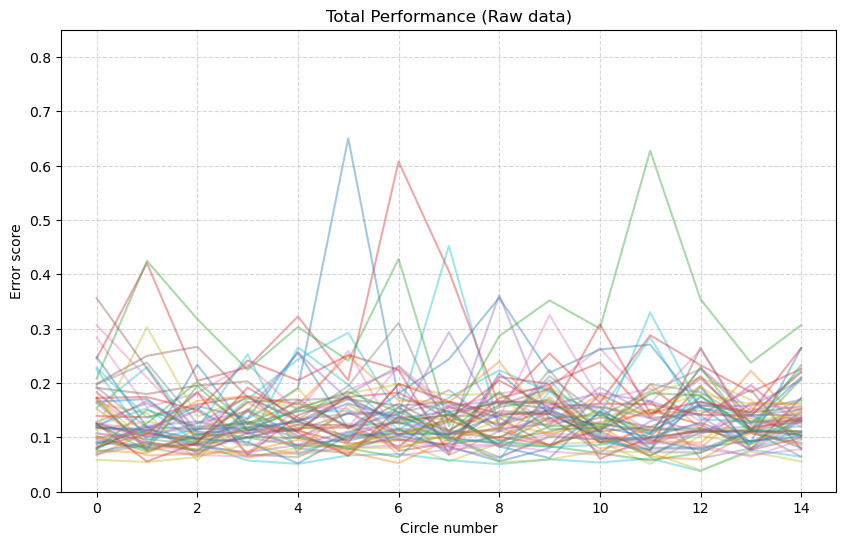

In [4]:
plt.figure(figsize=(10, 6))
for i, row in raw_df.iterrows():
    plt.plot(range(0, raw_df.shape[1]), row.values, alpha=0.4)  # faint line for each subject

plt.title("Total Performance (Raw data)")
plt.xlabel("Circle number")
plt.ylabel("Error score")
plt.ylim(0, 0.85)
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

### Clean up the data by removing outliers

In [5]:
# can allow for more outliers for fatigue - less difficult to determine
std_dev = 3 # how many standard deviations from the mean data can be

# calculate z scores
z_scores = (raw_df - raw_df.mean()) / raw_df.std()

# replace values with NaN if they’re more than determined standard deviations from the mean
df_clean = raw_df.mask(np.abs(z_scores) > std_dev)

# fill NaN with the median of that column instead of dropping
df_clean = df_clean.apply(lambda x: x.fillna(x.median()), axis=0)

#### Visualize cleaned up data

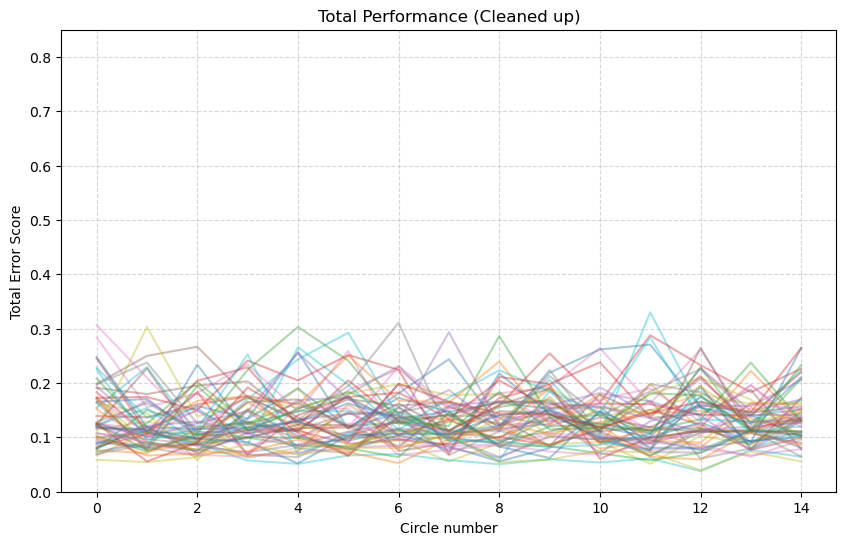

In [6]:
plt.figure(figsize=(10, 6))
for i, row in df_clean.iterrows():
    plt.plot(range(0, raw_df.shape[1]), row.values, alpha=0.4)  # faint line for each subject

plt.title("Total Performance (Cleaned up)")
plt.xlabel("Circle number")
plt.ylabel("Total Error Score")
plt.ylim(0, 0.85)
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# Determine percentage change at various window sizes

## Make function to calculate the change

In [7]:
def get_change(start, end):
    difference = end - start
    change = difference / start
    percent_change = change * 100
    return percent_change

## Calculate each percentage change

In [8]:
if not small_only:
    window_sizes = [4, 8, 12, 16, 20]
else:
    window_sizes = [3, 6, 9, 12, 15] # good balance of short and long term

percent_dict = {}

for window in window_sizes:
    all_percents = []
    for i, row in df_clean.iterrows():
        errors = row.values
        for start in range(len(errors) - window + 1):
            start_val = errors[start]

            end_val = errors[start + window - 1]

            all_percents.append(get_change(start_val, end_val))

    percent_dict[window] = np.array(all_percents)

### Plot each percentage change

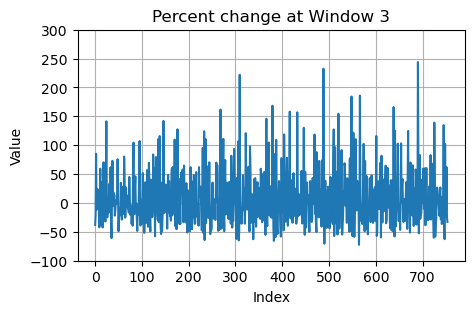

Number of percent samples: 754


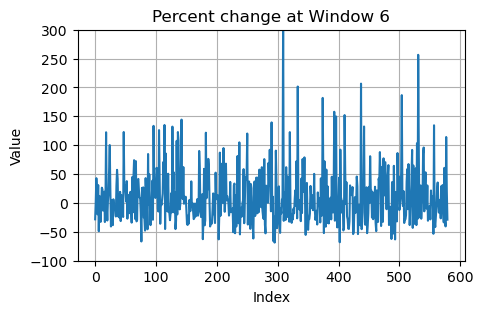

Number of percent samples: 580


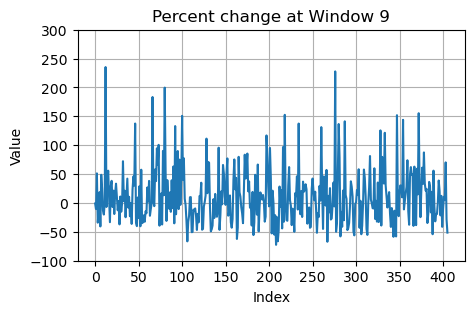

Number of percent samples: 406


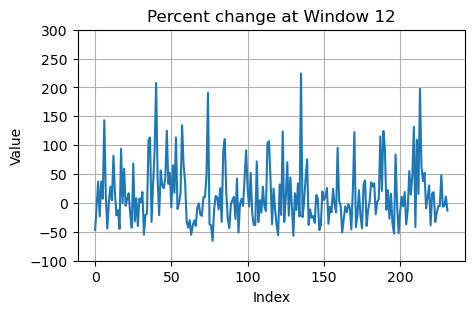

Number of percent samples: 232


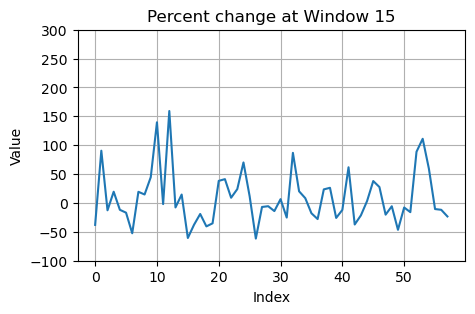

Number of percent samples: 58


In [9]:
for window, percent in percent_dict.items():
    plt.figure(figsize=(5, 3))
    plt.plot(range(len(percent)), percent)
    plt.title(f'Percent change at Window {window}')
    plt.xlabel('Index')
    plt.ylabel('Value')
    plt.ylim(-100, 300)
    plt.grid(True)
    plt.show()
    print("Number of percent samples:", len(percent))

### Clean up and remove outliers

In [10]:
# can allow for more outliers for fatigue - less difficult to determine
std_dev = 3  # how many standard deviations from the mean data can be

# replace outliers with median for each window
percent_dict_cleaned = {}

for window, percents in percent_dict.items():
    # calculate z-scores
    mean = np.nanmean(percents)
    std = np.nanstd(percents)
    z_scores = (percents - mean) / std
    
    # replace values with NaN if they're more than std_dev standard deviations from mean
    percents_masked = np.where(np.abs(z_scores) > std_dev, np.nan, percents)
    
    # fill NaN with the median
    median = np.nanmedian(percents_masked)
    percents_cleaned = np.where(np.isnan(percents_masked), median, percents_masked)
    
    percent_dict_cleaned[window] = percents_cleaned
    
    # print replacement statistics
    n_replaced = np.sum(np.abs(z_scores) > std_dev)
    pct_replaced = 100 * n_replaced / len(percents)
    print(f"Window {window}: Replaced {n_replaced} outliers ({pct_replaced:.1f}%) with median {median:.4f}")

# use cleaned data for downstream analysis
percent_dict = percent_dict_cleaned

Window 3: Replaced 11 outliers (1.5%) with median 0.4741
Window 6: Replaced 7 outliers (1.2%) with median -0.1307
Window 9: Replaced 4 outliers (1.0%) with median 3.7521
Window 12: Replaced 4 outliers (1.7%) with median 1.4699
Window 15: Replaced 1 outliers (1.7%) with median -5.6911


#### Plot cleaned up percent changes

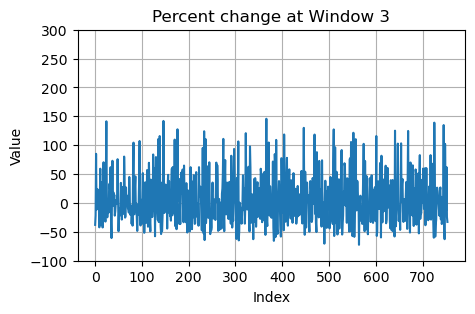

Number of percent samples: 754


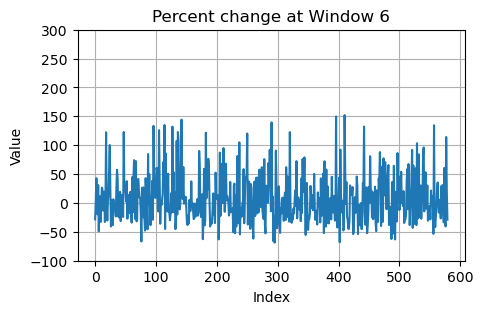

Number of percent samples: 580


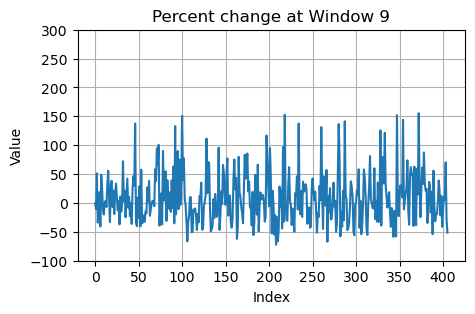

Number of percent samples: 406


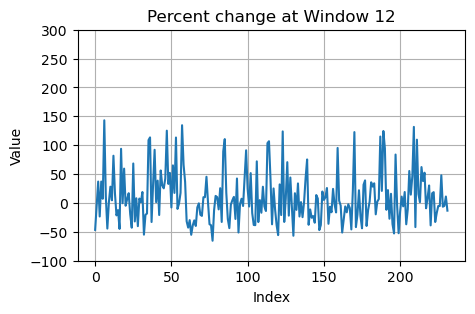

Number of percent samples: 232


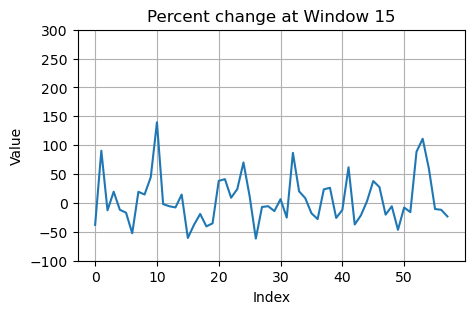

Number of percent samples: 58


In [11]:
for window, percent in percent_dict.items():
    plt.figure(figsize=(5, 3))
    plt.plot(range(len(percent)), percent)
    plt.title(f'Percent change at Window {window}')
    plt.xlabel('Index')
    plt.ylabel('Value')
    plt.ylim(-100, 300)
    plt.grid(True)
    plt.show()
    print("Number of percent samples:", len(percent))

# Use Gaussian Mixture Model to label

## Find thresholds for given probability

In [12]:
desired_probability = 0.95

In [ ]:
conf_percent = str(desired_probability * 100) + "%"
thresholds = {}
gmm_results = {}

for window, percent in percent_dict.items():
    percents_reshaped = percent.reshape(-1, 1) # reshape the percents
    gmm = BayesianGaussianMixture(n_components=3, n_init=1000, tol=0.001) # create GMM
    gmm.fit(percents_reshaped) # fit the GMM to the data
    
    # sort components
    means = gmm.means_.flatten()

    sigmas = np.sqrt(gmm.covariances_.flatten())

    order = np.argsort(means)
    means, sigmas, weights = means[order], sigmas[order], gmm.weights_[order]
    
    # compute posteriors over value range
    x = np.linspace(np.min(percent), np.max(percent), 10000)
    # probability distribution function
    pdfs = np.array([w * norm.pdf(x, m, s) for w, m, s in zip(weights, means, sigmas)])
    posteriors = pdfs / np.sum(pdfs, axis=0)
    
    # confidence thresholds
    # learning group is index 0
    learning_cutoff = x[np.where(posteriors[0] >= desired_probability)[0][-1]] if np.any(posteriors[0] >= desired_probability) else np.nan
    # fatigue group is index 2
    fatigue_cutoff = x[np.where(posteriors[2] >= desired_probability)[0][0]] if np.any(posteriors[2] >= desired_probability) else np.nan

    thresholds[window] = {
        "learning_cutoff": learning_cutoff,
        "fatigue_cutoff": fatigue_cutoff,
        "means": means,
    }
    gmm_results[window] = {"means": means, "sigmas": sigmas, "weights": weights}

# display thresholds
for w, t in thresholds.items():
    print(f"Window {w}:")
    print(f"  {conf_percent} Learning cutoff: {t['learning_cutoff']:.4f}")
    print(f"  {conf_percent} Fatigue cutoff: {t['fatigue_cutoff']:.4f}")


## Display GMM findings

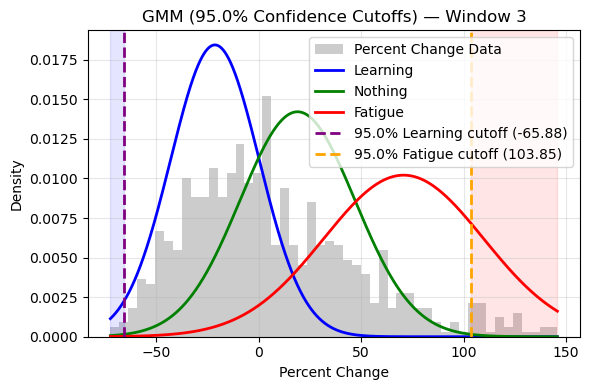

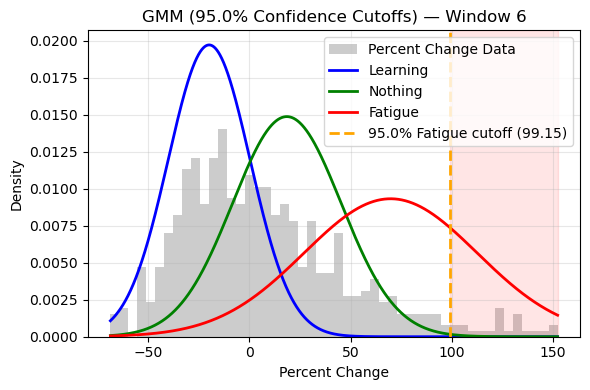

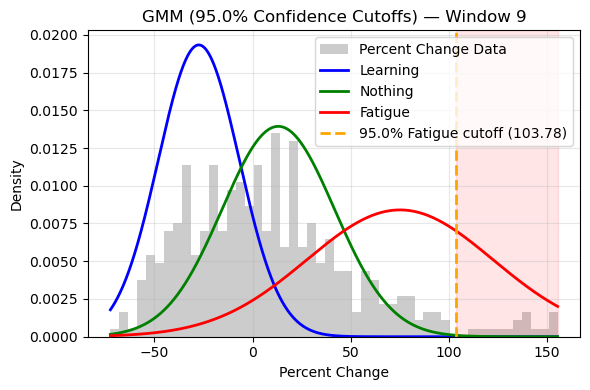

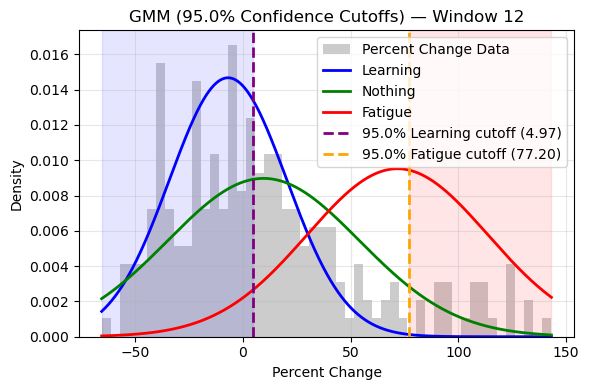

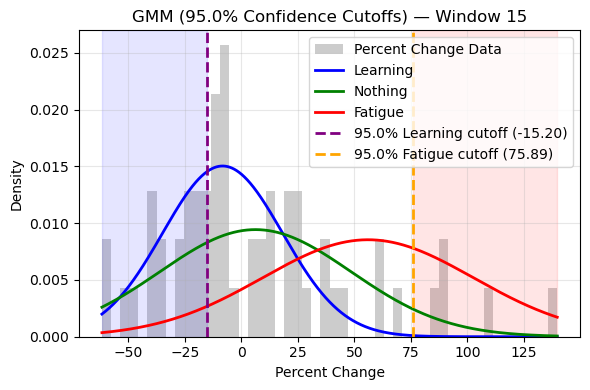

In [ ]:
for window in window_sizes: 
    results = gmm_results[window]
    means = results["means"]
    sigmas = results["sigmas"]
    percents = percent_dict[window]

    # compute Gaussian PDFs
    x = np.linspace(np.nanmin(percents), np.nanmax(percents), 10000)
    pdfs = [norm.pdf(x, mu, sigma) for mu, sigma in zip(means, sigmas)]
    
    # extract confidence cutoffs
    t_learning = thresholds[window]["learning_cutoff"]
    t_fatigue = thresholds[window]["fatigue_cutoff"]

    # plot histogram
    plt.figure(figsize=(6, 4))
    plt.hist(percents, bins=50, density=True, alpha=0.4, color='gray', label='Percent Change Data')

    # plot Gaussians
    colors = ['blue', 'green', 'red']
    labels = ['Learning', 'Nothing', 'Fatigue']
    for pdf, color, label in zip(pdfs, colors, labels):
        plt.plot(x, pdf, color=color, lw=2, label=label)

    # shaded regions for high-confidence areas
    if not np.isnan(t_learning):
        plt.axvspan(x.min(), t_learning, color='blue', alpha=0.1)
    if not np.isnan(t_fatigue):
        plt.axvspan(t_fatigue, x.max(), color='red', alpha=0.1)

    # plot Sconfidence cutoffs
    if not np.isnan(t_learning):
        plt.axvline(t_learning, color='purple', linestyle='--', lw=2, label=f'{conf_percent} Learning cutoff ({t_learning:.2f})')
    if not np.isnan(t_fatigue):
        plt.axvline(t_fatigue, color='orange', linestyle='--', lw=2, label=f'{conf_percent} Fatigue cutoff ({t_fatigue:.2f})')

    
    plt.title(f"GMM ({conf_percent} Confidence Cutoffs) — Window {window}")
    plt.xlabel("Percent Change")
    plt.ylabel("Density")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

## Ensure GMM thresholds are statistically significant

### H0 = The percent change at or beyond the calculated threshold is due to random variation

### H1 = The percent change at or beyond the calculated threshold is not due to random variation

In [ ]:
for w, t in thresholds.items():
    print(Fore.CYAN + f"Window {w}: mean percent change is {statistics.mean(percent_dict[w])}")
    t_stat, p_value = stats.ttest_1samp(percent_dict[w], t['learning_cutoff'])
    if (p_value < 0.001):
        print(Fore.GREEN + f"Learning threshold = {t['learning_cutoff']:.4f} is statistically significant with a p-value of {p_value}") 
    else:
        print(Fore.RED + f"Learning threshold = {t['learning_cutoff']:.4f} is NOT statistically significant with a p-value of {p_value}")
    t_stat, p_value = stats.ttest_1samp(percent_dict[w], t['fatigue_cutoff'])
    if (p_value < 0.001):
        print(Fore.GREEN + f"Fatigue threshold = {t['fatigue_cutoff']:.4f} is statistically significant with a p-value of {p_value}")
    else:
        print(Fore.RED + f"Fatigue threshold = {t['fatigue_cutoff']:.4f} is NOT statistically significant with a p-value of {p_value}")


print("NOTE: Only using fatigue values.")

Window 3: mean percent change is 6.734356501084799
Learning threshold = -65.8842 is statistically significant with a p-value of 7.581973410127999e-228
Fatigue threshold = 103.8513 is statistically significant with a p-value of 1.0303252976242248e-303
Window 6: mean percent change is 7.193245797106916
Learning threshold = nan is NOT statistically significant with a p-value of nan
Fatigue threshold = 99.1486 is statistically significant with a p-value of 2.2944785835022475e-225
Window 9: mean percent change is 8.984501170226782
Learning threshold = nan is NOT statistically significant with a p-value of nan
Fatigue threshold = 103.7828 is statistically significant with a p-value of 2.409668083579296e-154
Window 12: mean percent change is 9.64084971754037
Learning threshold = 4.9737 is NOT statistically significant with a p-value of 0.11145825794016323
Fatigue threshold = 77.1964 is statistically significant with a p-value of 4.7196035064222285e-62
Window 15: mean percent change is 6.22792

## Visualize thresholds in trials

### Prepare for visualization

In [ ]:
window = 3 # size of window - user determined

In [ ]:
fatigue_threshold = thresholds[window]["fatigue_cutoff"]
print(f"Fatigue threshold: {fatigue_threshold}")

modes_list = []

for i, row in df_clean.iterrows():
    subject_modes = []
    errors = row.values
    for start in range(len(errors) - window + 1):
        window_vals = errors[start:start+window]
        x = np.arange(window)
        
        start_val = errors[start]

        end_val = errors[start + window - 1]

        percent_changed = get_change(start_val, end_val)

        if percent_changed > fatigue_threshold:
            subject_modes.append("fatigued")
        else:
            subject_modes.append("nothing")
    
    # pad the beginning so the mode array is same length as trials - no reading at the beginning
    subject_modes = ["nothing"]*(window-1) + subject_modes
    modes_list.append(subject_modes)

# convert to DataFrame for easy handling
modes_df = pd.DataFrame(modes_list, index=df_clean.index, columns=df_clean.columns)

Fatigue threshold: 103.85127622053028


### Visualize at given window

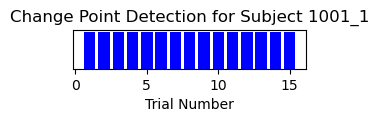

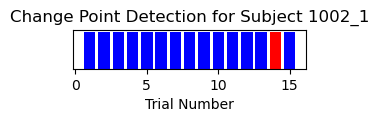

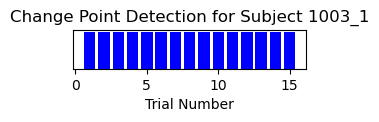

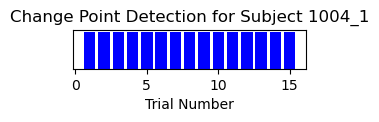

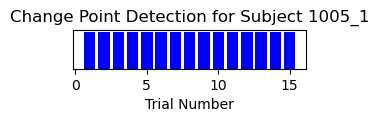

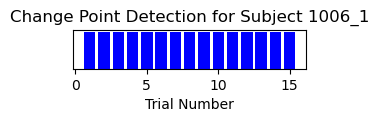

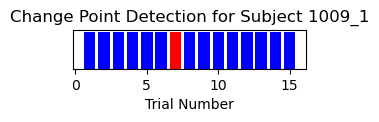

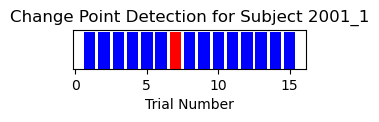

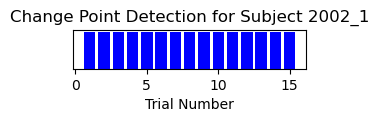

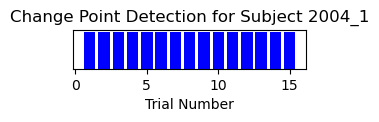

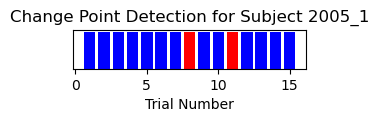

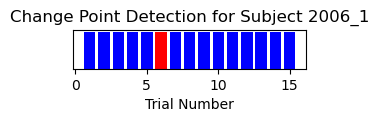

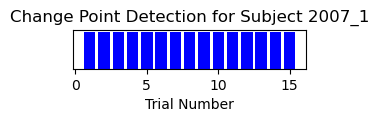

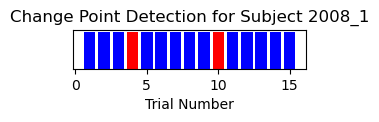

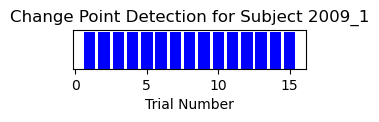

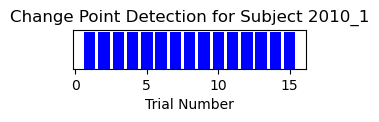

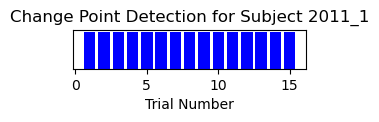

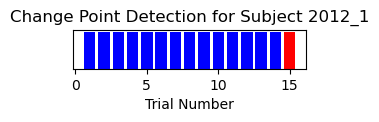

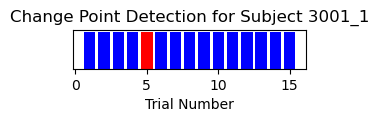

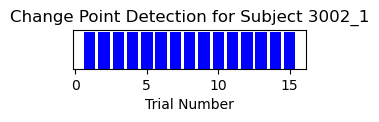

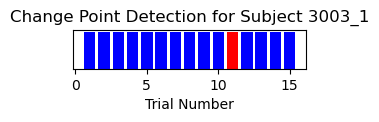

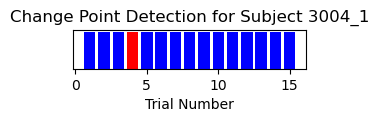

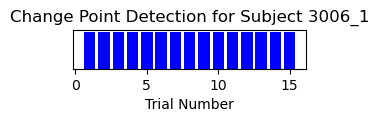

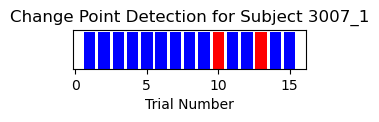

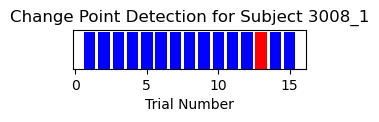

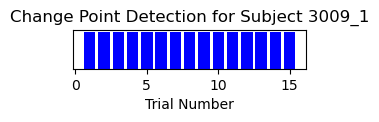

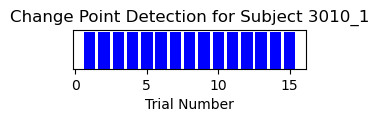

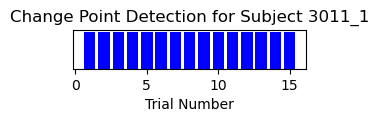

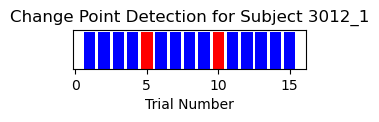

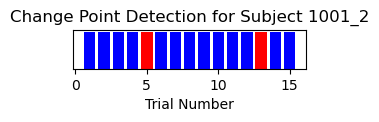

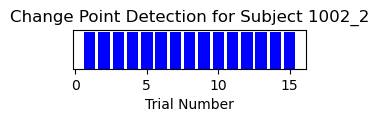

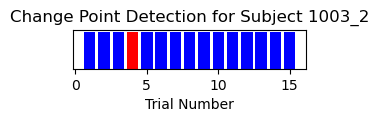

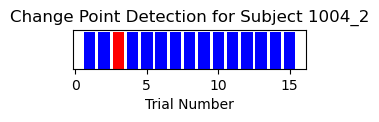

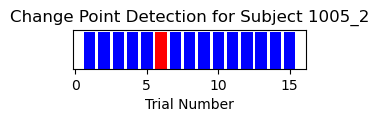

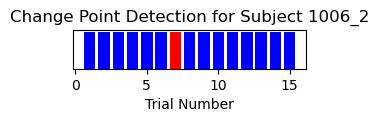

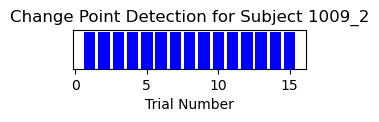

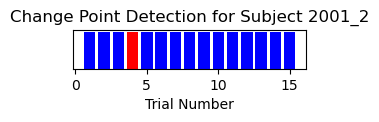

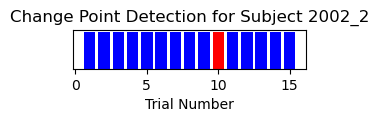

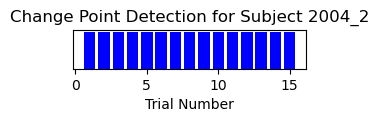

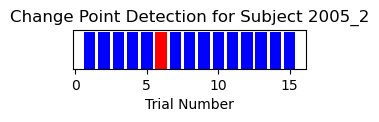

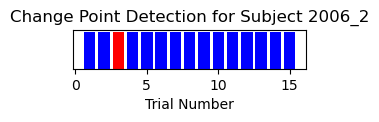

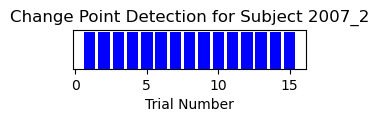

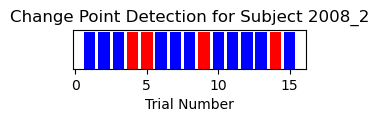

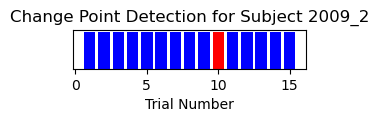

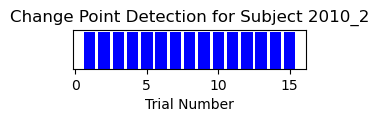

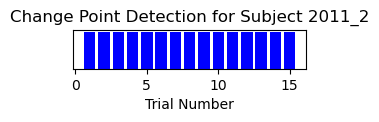

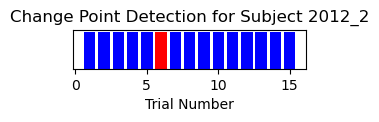

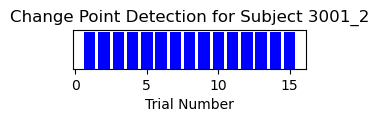

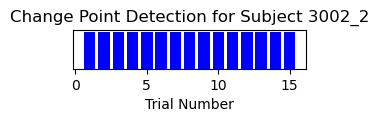

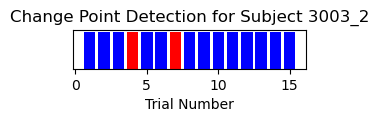

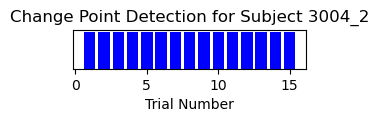

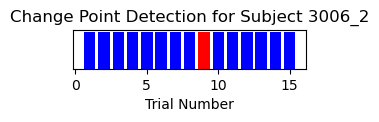

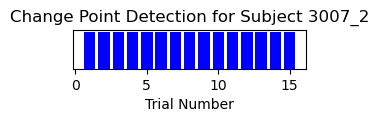

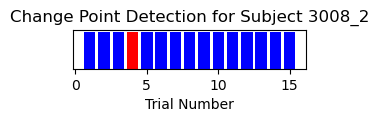

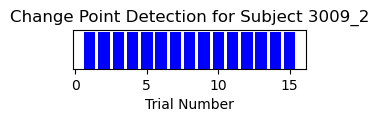

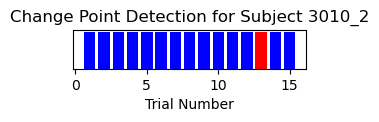

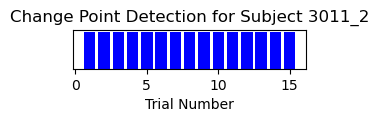

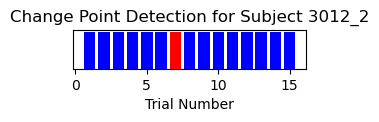

In [ ]:
for i in range(0,raw_df.shape[0]):
    subject = i
    colors = {"nothing": "blue", "fatigued": "red"}
    modes = modes_df.iloc[subject]

    plt.figure(figsize=(3,0.5))
    for i, mode in enumerate(modes):
        plt.bar(i+1, 1, color=colors[mode])

    plt.title(f"Change Point Detection for Subject {df_clean.index[subject]}")
    plt.xlabel("Trial Number")
    plt.yticks([])
    plt.show()

# Display with consistency findings

In [ ]:
with open('consistency_thresholds.pkl', 'rb') as f:
    consistency_thresholds = pickle.load(f)

# Display combining sets

## Combine percent change

In [ ]:
print(f"Fatigue threshold: {fatigue_threshold}")
print(f"Variance threshold: {variance_threshold}")

combined_modes_list = []

# process each unique subject (combining both sets)
num_unique_subjects = len(df_clean) // 2

for subject_idx in range(num_unique_subjects):
    set1_idx = subject_idx
    set2_idx = subject_idx + num_unique_subjects
    
    # get data from both sets
    errors_set1 = df_clean.iloc[set1_idx].values
    errors_set2 = df_clean.iloc[set2_idx].values
    
    # process set 1
    subject_modes_set1 = []
    for start in range(len(errors_set1) - window + 1):
        window_vals = errors_set1[start:start+window]
           
        start_val = errors_set1[start]

        end_val = errors_set1[start + window - 1]

        percent_changed = get_change(start_val, end_val)

        window_variance = np.var(window_vals, ddof=1)

        if window_variance >= variance_threshold:
            subject_modes_set1.append("inconsistent")
        elif percent_changed > fatigue_threshold:
            subject_modes_set1.append("fatigued")
        else:
            subject_modes_set1.append("nothing")
    
    # pad set 1
    subject_modes_set1 = ["nothing"]*(window-1) + subject_modes_set1
    
    # process set 2
    subject_modes_set2 = []
    for start in range(len(errors_set2) - window + 1):
        window_vals = errors_set2[start:start+window]
          
        start_val = errors_set2[start]

        end_val = errors_set2[start + window - 1]

        percent_changed = get_change(start_val, end_val)

        window_variance = np.var(window_vals, ddof=1) 

        if window_variance >= variance_threshold:
            subject_modes_set2.append("inconsistent")
        elif percent_changed > fatigue_threshold:
            subject_modes_set2.append("fatigued")
        else:
            subject_modes_set2.append("nothing")
    
    # pad set 2
    subject_modes_set2 = ["nothing"]*(window-1) + subject_modes_set2
    
    # combine both sets
    subject_modes = subject_modes_set1 + subject_modes_set2
    combined_modes_list.append(subject_modes)

# create combined labels
combined_subject_labels = [df_clean.index[i].split('_')[0] for i in range(num_unique_subjects)]

# convert to DataFrame for easy handling
combined_modes_df = pd.DataFrame(combined_modes_list, index=combined_subject_labels)

Fatigue threshold: 103.85127622053028
Variance threshold: 0.004206264678303222


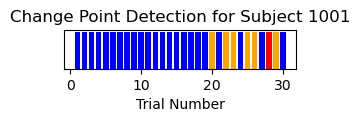

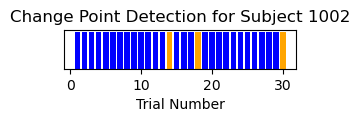

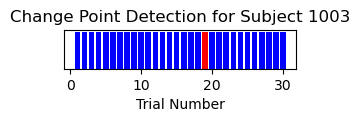

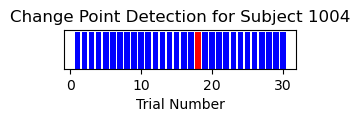

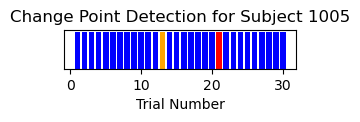

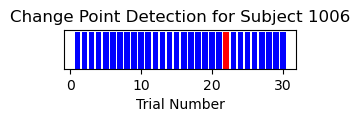

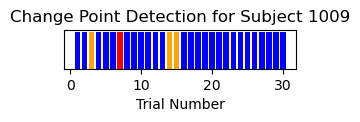

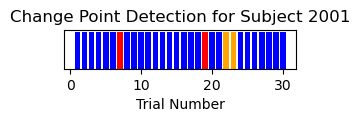

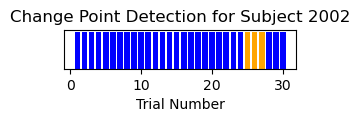

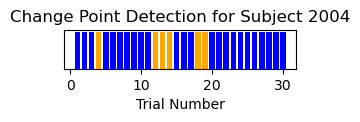

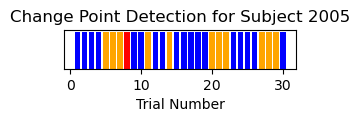

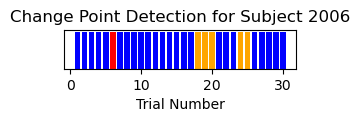

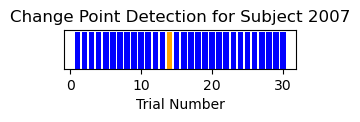

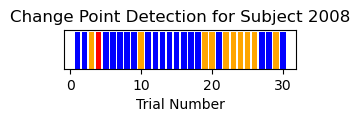

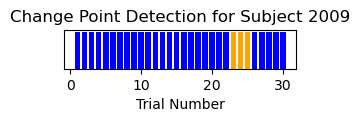

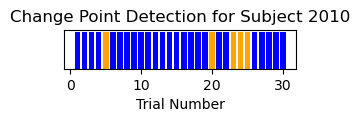

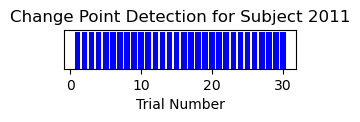

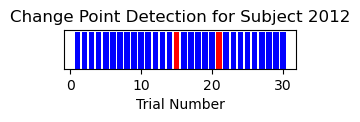

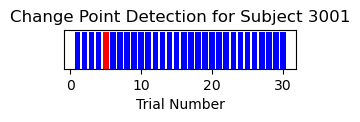

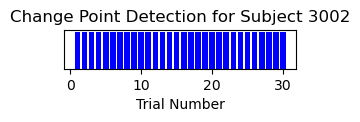

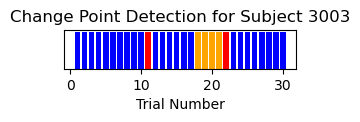

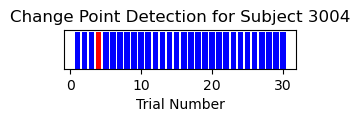

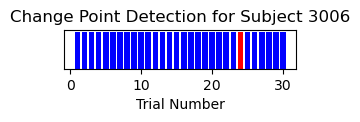

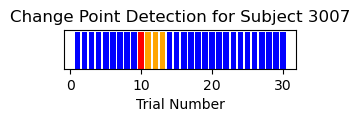

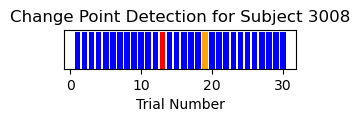

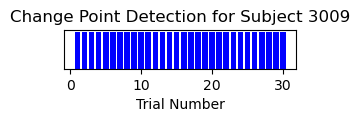

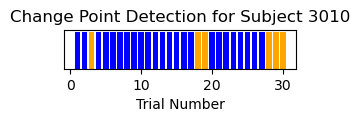

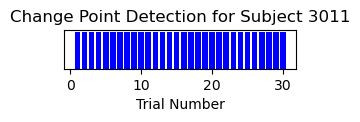

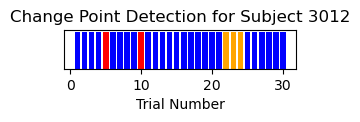

In [ ]:
# plot each combined subject
for subject_idx in range(len(combined_modes_df)):
    colors = {"nothing": "blue", "fatigued": "red", "inconsistent": "orange"}
    modes = combined_modes_df.iloc[subject_idx]

    plt.figure(figsize=(3,0.5))  # made wider to accommodate combined data
    for i, mode in enumerate(modes):
        plt.bar(i+1, 1, color=colors[mode])

    plt.title(f"Change Point Detection for Subject {combined_modes_df.index[subject_idx]}")
    plt.xlabel("Trial Number")
    plt.yticks([])
    plt.show()